# QSP-PhaseEstimation Test

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import gridspec
from matplotlib.transforms import Bbox, TransformedBbox, blended_transform_factory
from mpl_toolkits.axes_grid1.inset_locator import BboxPatch, BboxConnector, BboxConnectorPatch
import seaborn as sns
from tqdm import tqdm

from solving_optimally_designed_signal import solve_optimally_designed_signal
from iterative_refinement_scheme import iterative_refinement_scheme

## Solving optimally designed signal

In [2]:
# ── Sweep parameters ───────────────────────────────────────────────────────────
theta0   = 0.5
zeta     = 2
d_values = [2, 4, 8, 16, 32, 64]

entries = []

for d in tqdm(d_values, desc="Sweeping d"):
    r = 1.0 / (4 * d * zeta)   # prior radius consistent with solver internals

    print(f"\nSolving for d={d}, theta0={theta0:.6f}, r={r:.6f} ...")
    ak_scaled, L = solve_optimally_designed_signal(
        d, theta0, r, zeta=zeta
    )

    if ak_scaled is None:
        print(f"  [WARNING] No solution for d={d}, skipping.")
        continue

    entries.append({
        'a_coeffs':     ak_scaled,
        'r':            r,
        'd':            d,
        'theta_center': theta0,
        'zeta':         zeta,
    })
    print(f"  d={d} done. L={L:.4f}")

entries = sorted(entries, key=lambda e: e['d'])
print(f"\nSweep complete: d = {[e['d'] for e in entries]}")

Sweeping d:   0%|          | 0/6 [00:00<?, ?it/s]


Solving for d=2, theta0=0.500000, r=0.062500 ...
Restricted license - for non-production use only - expires 2027-11-29


Sweeping d:  17%|█▋        | 1/6 [00:01<00:06,  1.38s/it]

  d=2 done. L=1.5830

Solving for d=4, theta0=0.500000, r=0.031250 ...


Sweeping d:  33%|███▎      | 2/6 [00:02<00:05,  1.42s/it]

...

  d=16 done. L=13.7522

Solving for d=32, theta0=0.500000, r=0.003906 ...


Sweeping d:  83%|████████▎ | 5/6 [00:14<00:03,  3.64s/it]

  d=32 done. L=27.4774

Solving for d=64, theta0=0.500000, r=0.001953 ...


Sweeping d: 100%|██████████| 6/6 [00:25<00:00,  4.19s/it]

  d=64 done. L=57.1460

Sweep complete: d = [2, 4, 8, 16, 32, 64]


/var/folders/1k/wfwgsdr57xz4qwc3p5r0l92h0000gq/T/ipykernel_17713/3358773952.py:159: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  f_coeffs[0] = np.trapz(f_int, th_int) / np.pi
/var/folders/1k/wfwgsdr57xz4qwc3p5r0l92h0000gq/T/ipykernel_17713/3358773952.py:161: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  f_coeffs[n] = 2 * np.trapz(f_int * np.cos(n * th_int), th_int) / np.pi


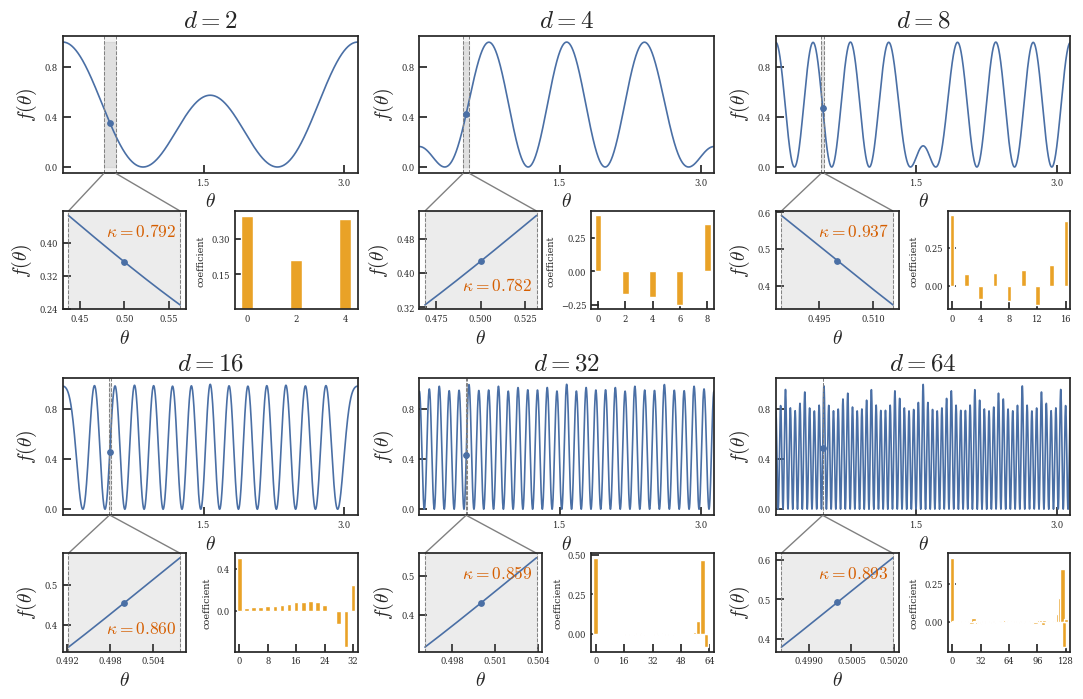

In [3]:
# ── Style ──────────────────────────────────────────────────
sns.set_theme(style="ticks")
plt.rcParams.update({
    "text.usetex":         False,
    "mathtext.fontset":    "cm",
    "font.family":         "serif",
    "font.serif":          ["Computer Modern Roman", "DejaVu Serif", "Times New Roman"],
    "axes.spines.top":     True,
    "axes.spines.right":   True,
    "font.size":           7,
    "axes.labelsize":      7,
    "axes.titlesize":      8,
    "legend.fontsize":     6,
    "xtick.labelsize":     6,
    "ytick.labelsize":     6,
    "xtick.direction":     "in",
    "ytick.direction":     "in",
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
})

pal       = sns.color_palette("colorblind", n_colors=6)
C_signal  = "#4A6FA5"
C_tangent = pal[3]
C_bar     = "#E9A227"
C_prior   = "gray"

THETA0 = theta0


# ── Signal helpers ─────────────────────────────────────────────────────────────
def g(theta, ak):
    indices = [2 * k for k in range(len(ak))]
    theta   = np.asarray(theta)
    return np.vstack([np.cos(idx * theta) for idx in indices]).T.dot(ak)

def gp(theta, ak):
    indices = [2 * k for k in range(len(ak))]
    theta   = np.asarray(theta)
    return np.vstack([-idx * np.sin(idx * theta) for idx in indices]).T.dot(ak)

def _set_ticks(ax, n=3):
    for axis in (ax.xaxis, ax.yaxis):
        axis.set_major_locator(ticker.MaxNLocator(nbins=n, min_n_ticks=2, prune='both'))
        axis.set_minor_locator(ticker.NullLocator())

def connect_bbox(bbox1, bbox2, loc1a, loc2a, loc1b, loc2b, prop_lines, prop_patches=None):
    if prop_patches is None:
        prop_patches = {**prop_lines, "alpha": prop_lines.get("alpha", 1) * 0.2}
    prop_patches2 = {**prop_lines, "alpha": 0}
    c1 = BboxConnector(bbox1, bbox2, loc1=loc1a, loc2=loc2a, **prop_lines); c1.set_clip_on(False)
    c2 = BboxConnector(bbox1, bbox2, loc1=loc1b, loc2=loc2b, **prop_lines); c2.set_clip_on(False)
    bp1 = BboxPatch(bbox1, **prop_patches)
    bp2 = BboxPatch(bbox2, **prop_patches2)
    p   = BboxConnectorPatch(bbox1, bbox2, loc1a=loc1a, loc2a=loc2a,
                             loc1b=loc1b, loc2b=loc2b, **prop_patches2)
    p.set_clip_on(False)
    return c1, c2, bp1, bp2, p

def zoom_effect(ax1, ax2, xmin, xmax, **kwargs):
    t1 = blended_transform_factory(ax1.transData, ax1.transAxes)
    t2 = blended_transform_factory(ax2.transData, ax2.transAxes)
    bb  = Bbox.from_extents(xmin, 0, xmax, 1)
    mb1 = TransformedBbox(bb, t1)
    mb2 = TransformedBbox(bb, t2)
    pp  = {**kwargs, "ec": "none", "alpha": 0.1}
    c1, c2, bp1, bp2, p = connect_bbox(mb1, mb2, 3, 2, 4, 1, prop_lines=kwargs, prop_patches=pp)
    ax1.add_patch(bp1); ax2.add_patch(bp2)
    ax2.add_patch(c1);  ax2.add_patch(c2); ax2.add_patch(p)


# ── κ label position per panel ─────────────────────────────────────────────────
# Entry order matches entries[] sorted by d: d=2, 4, 8, 16, 32, 64
KAPPA_POS = [
    (0.92, 0.7,  'right'),   # d=2
    (0.92, 0.15, 'right'),   # d=4
    (0.92, 0.7,  'right'),   # d=8
    (0.92, 0.15, 'right'),   # d=16
    (0.92, 0.7,  'right'),   # d=32
    (0.92, 0.7,  'right'),   # d=64
]


# ── 2×3 figure ─────────────────────────────────────────────────────────────────
NROWS, NCOLS = 2, 3
fig = plt.figure(figsize=(13, 8))
outer = gridspec.GridSpec(NROWS, NCOLS, figure=fig, hspace=0.25, wspace=0.21)

theta = np.linspace(0, np.pi, 2000)

for idx, entry in enumerate(entries):
    row, col = divmod(idx, NCOLS)

    ak = entry['a_coeffs']
    rk = entry['r']
    d  = int(entry['d'])

    theta_left  = THETA0 - rk
    theta_right = THETA0 + rk
    theta_prior = np.linspace(theta_left, theta_right, 800)

    f_vals        = g(theta, ak) ** 2
    f_vals_prior  = g(theta_prior, ak) ** 2
    fp_vals_prior = 2 * g(theta_prior, ak) * gp(theta_prior, ak)
    g_theta0      = g(np.array(THETA0), ak)

    inner = gridspec.GridSpecFromSubplotSpec(
        2, 2,
        subplot_spec=outer[row, col],
        height_ratios=[1.4, 1],
        hspace=0.32, wspace=0.40,
    )
    ax_top   = fig.add_subplot(inner[0, :])
    ax_zoom  = fig.add_subplot(inner[1, 0])
    ax_coeff = fig.add_subplot(inner[1, 1])

    # ── Top: full signal ──────────────────────────────────────────────────────
    ax_top.plot(theta, f_vals, color=C_signal, lw=1.2)
    ax_top.scatter(THETA0, g_theta0 ** 2, color=C_signal, zorder=5, s=15)
    ax_top.axvline(theta_left,  color=C_prior, linestyle='--', lw=0.7)
    ax_top.axvline(theta_right, color=C_prior, linestyle='--', lw=0.7)
    ax_top.fill_between(theta, 0, 1,
                        where=(theta >= theta_left) & (theta <= theta_right),
                        color=C_prior, alpha=0.15)
    ax_top.set_xlim(0, np.pi)
    ax_top.set_ylim(-0.05, 1.05)
    ax_top.set_title(r'$d = {}$'.format(d), fontsize=18)
    ax_top.set_xlabel(r'$\theta$', fontsize=14)
    ax_top.set_ylabel(r'$f(\theta)$', fontsize=14)
    _set_ticks(ax_top)

    # ── Bottom-left: zoom + κ ─────────────────────────────────────────────────
    idx_min = np.argmin(np.abs(fp_vals_prior))
    L       = np.abs(fp_vals_prior[idx_min])
    kappa   = L / d

    kx, ky, kha = KAPPA_POS[idx]

    ax_zoom.plot(theta_prior, f_vals_prior, color=C_signal, lw=1.2)
    ax_zoom.axvline(theta_left,  color=C_prior, linestyle='--', lw=0.7)
    ax_zoom.axvline(theta_right, color=C_prior, linestyle='--', lw=0.7)
    ax_zoom.axvspan(theta_left, theta_right, color=C_prior, alpha=0.15)
    ax_zoom.scatter(THETA0, g_theta0 ** 2, color=C_signal, zorder=5, s=15)
    ax_zoom.set_xlabel(r'$\theta$', fontsize=14)
    ax_zoom.set_ylabel(r'$f(\theta)$', fontsize=14)
    ax_zoom.text(kx, ky, fr'$\kappa={kappa:.3f}$',
                 transform=ax_zoom.transAxes,
                 ha=kha, va='bottom',
                 fontsize=12.5, color=C_tangent)
    _set_ticks(ax_zoom)
    zoom_effect(ax_top, ax_zoom, theta_left, theta_right, color=C_prior)

    # ── Bottom-right: Fourier cosine coefficients of f = g² ──────────────────
    N_int    = 8000
    th_int   = np.linspace(0, np.pi, N_int)
    f_int    = g(th_int, ak) ** 2
    max_mode = 2 * d
    f_coeffs = np.zeros(max_mode + 1)
    f_coeffs[0] = np.trapz(f_int, th_int) / np.pi
    for n in range(2, max_mode + 1, 2):
        f_coeffs[n] = 2 * np.trapz(f_int * np.cos(n * th_int), th_int) / np.pi

    even_modes = np.arange(0, max_mode + 1, 2)
    bar_width  = max(0.5, max_mode * 0.04)
    ax_coeff.bar(even_modes, f_coeffs[even_modes], width=bar_width, color=C_bar)

    tick_step = max(2, (max_mode // 4) // 2 * 2)
    ax_coeff.xaxis.set_major_locator(ticker.FixedLocator(np.arange(0, max_mode + 1, tick_step)))
    ax_coeff.xaxis.set_minor_locator(ticker.NullLocator())
    ax_coeff.set_ylabel('coefficient')
    ax_coeff.set_xlim(-bar_width, max_mode + bar_width)
    _set_ticks(ax_coeff, n=3)
    ax_coeff.xaxis.set_major_locator(ticker.FixedLocator(np.arange(0, max_mode + 1, tick_step)))

    for ax in (ax_top, ax_zoom, ax_coeff):
        for spine in ax.spines.values():
            spine.set_visible(True)

plt.show()

## Iterative Refinement Scheme

In [6]:
theta_true     = 0.5
theta_hat_prev = 0.508  # make it within 1/(4\zeta d_k_prev)
d_k_prev       = 4
zeta           = np.sqrt(10)
q_factor       = 2
r_k_prev       = 1 / (4 * d_k_prev * q_factor * zeta)
mk             = 1000

theta_hat_k, error_k, r_k, Lk = iterative_refinement_scheme(
    theta_true, theta_hat_prev, r_k_prev, d_k_prev, q_factor, mk, zeta
)
print(f"Refined estimate: {theta_hat_k}")
print(f"Error:            {error_k}")
print(f"New radius:       {r_k}")
print(f"Lk:               {Lk}")
print(f"kappa:           {Lk/(d_k_prev*q_factor)}")

Refined estimate: 0.5002549993970472
Error:            0.0002549993970472064
New radius:       0.004941058844013093
Lk:               7.317752079810021
kappa:           0.9147190099762527
